# 04 - Post-hoc objective-gradient guidance

Gaussian/PCA noise alignment is efficient because its correction can be
computed with forward passes and small linear operations, but it can use only
the structure captured by fitted means and covariances. A differentiable class
objective offers a more adaptive alternative: at each active sampling state,
its gradient points toward the local change that would raise the target score
of the model's denoised estimate. The generator remains frozen, and the
direction is not aimed at a preset point, but obtaining it requires
backpropagation through the denoiser during sampling.


In [1]:
import sys
from pathlib import Path

NOTES_DIR = Path.cwd()
if not (NOTES_DIR / "toy_notes.py").exists():
    NOTES_DIR = Path("notebooks/toy_data")
sys.path.insert(0, str(NOTES_DIR.resolve()))

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from toy_notes import *

SEED = 2026
set_seed(SEED)
device = choose_device()
print(environment_summary(device))


{'torch': '2.9.1+cu128', 'device': 'cuda', 'gpu': 'NVIDIA RTX A6000', 'cuda': '12.8'}


In [2]:
model, losses, _ = load_or_train_model(device=device)
reference_data, reference_labels = sample_labeled_mixture(30000, device=device)
stats = estimate_gaussian_stats(reference_data, reference_labels)
TARGET_CLASS = 2


## 1. Why does an objective gradient provide a direction?

The three class Gaussians define `p(class | x)` in clean data space. During
sampling we first compute the model's denoised estimate `D_theta(x_t,t)`, then
differentiate `log p(target | D_theta)` with respect to the current state.

This is not a vector toward a preset coordinate. It is the gradient of a
class-level objective and changes with the state and time.


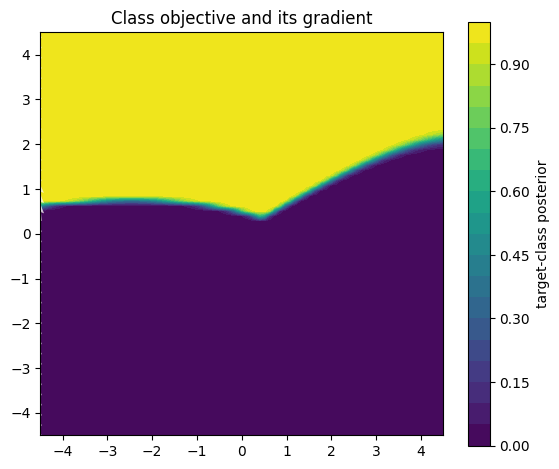

In [3]:
grid_1d = torch.linspace(-4.5, 4.5, 80, device=device)
gx, gy = torch.meshgrid(grid_1d, grid_1d, indexing="xy")
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1).requires_grad_(True)
posterior = class_log_probabilities(grid, stats).softmax(dim=1)[:, TARGET_CLASS]
gradient = torch.autograd.grad(torch.log(posterior.clamp_min(1e-8)).sum(), grid)[0]

probability_image = posterior.reshape(gx.shape).detach().cpu()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
contour = ax.contourf(gx.cpu(), gy.cpu(), probability_image, levels=20, cmap="viridis")
subset = torch.arange(0, grid.shape[0], 160, device=device)
direction = gradient[subset] / gradient[subset].norm(dim=1, keepdim=True).clamp_min(1e-6)
ax.quiver(
    grid[subset, 0].detach().cpu(), grid[subset, 1].detach().cpu(),
    direction[:, 0].detach().cpu(), direction[:, 1].detach().cpu(),
    color="white", alpha=0.75, scale=18,
)
fig.colorbar(contour, ax=ax, label="target-class posterior")
ax.set_title("Class objective and its gradient")
ax.set_aspect("equal")
plt.show()


## 2. Compare forward-only and backward-pass guidance

All methods again share the exact same initial noise. Gradient guidance is
active over the middle/late window, where the denoised estimate is informative.
The Gaussian/PCA method is active only at high noise.


In [4]:
set_seed(SEED + 40)
x0 = sample_base(1200, device=device)
target_reference = sample_class(1200, TARGET_CLASS, device=device)

methods = {
    "baseline": base_velocity(model),
    "PCA/Gaussian, forward only": make_noise_aligned_velocity(
        model, stats, target_class=TARGET_CLASS, strength=1.6
    ),
    "gradient 1.5": make_gradient_guided_velocity(
        model, stats, target_class=TARGET_CLASS, strength=1.5, start=0.15, end=0.92
    ),
    "gradient 3.0": make_gradient_guided_velocity(
        model, stats, target_class=TARGET_CLASS, strength=3.0, start=0.15, end=0.92
    ),
}

rows = []
paths = {}
for name, velocity in methods.items():
    path, seconds = timed_sample(velocity, x0, steps=48, method="heun")
    metrics = evaluate_samples(path[-1].to(device), target_reference, stats, target_class=TARGET_CLASS)
    rows.append({"method": name, **metrics, "seconds": seconds})
    paths[name] = path

gradient_table = pd.DataFrame(rows)
display(gradient_table.round(4))


,method,target_rate,target_wasserstein,mean_error,diversity_ratio,seconds
0,baseline,0.3533,2.3714,2.1642,16.5018,0.0410
1,"PCA/Gaussian, forward only",0.6408,1.2645,1.0503,12.0208,0.1766
2,gradient 1.5,0.5325,1.6350,1.4642,12.1231,0.3936
3,gradient 3.0,0.7300,0.9096,0.8435,7.4086,0.2582


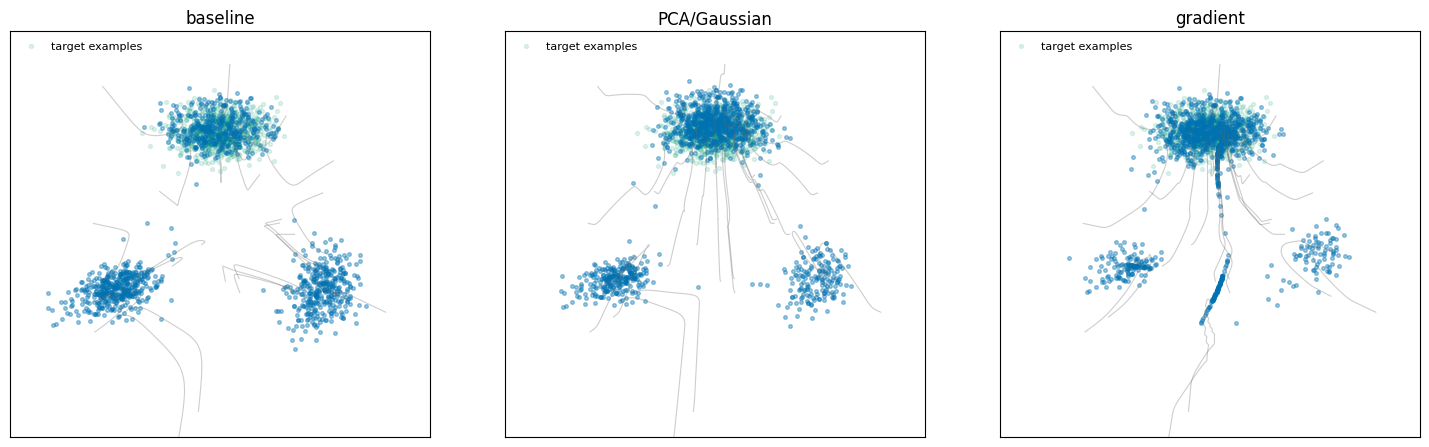

,method,target_rate,target_wasserstein,diversity_ratio,runtime / baseline
0,baseline,0.353,2.371,16.502,1.000
1,"PCA/Gaussian, forward only",0.641,1.264,12.021,4.312
2,gradient 1.5,0.533,1.635,12.123,9.609
3,gradient 3.0,0.730,0.910,7.409,6.303


In [5]:
plot_trajectory_comparison(
    {
        "baseline": paths["baseline"],
        "PCA/Gaussian": paths["PCA/Gaussian, forward only"],
        "gradient": paths["gradient 3.0"],
    },
    target_reference=target_reference[:700],
)
plt.show()

relative = gradient_table.copy()
relative["runtime / baseline"] = relative["seconds"] / relative.loc[0, "seconds"]
display(relative[["method", "target_rate", "target_wasserstein", "diversity_ratio", "runtime / baseline"]].round(3))


## Cost model

With Heun and 48 steps, the baseline makes 96 forward evaluations. Gradient
guidance can add a backward pass to most of those evaluations. The exact runtime
depends on hardware, but the computational distinction is structural:

| Method | Offline target data | Inference gradients | Main online work |
|---|---:|---:|---|
| Baseline | no | no | model forward passes |
| Gaussian/PCA | yes | no | forwards + small matrix-vector operations |
| Gradient guidance | yes or external classifier | yes | forwards + backward passes |

**Questions**

1. Why can a gradient become unreliable at very high noise?
2. Does the largest target rate also give the best target Wasserstein distance and diversity?
3. Which comparison isolates the price of inference-time backpropagation?

Objective-gradient guidance makes a different trade-off from noise alignment:
its direction adapts to the current state, but each active solver evaluation
requires backpropagation, and the signal is least trustworthy before the
denoised estimate carries useful class information. The next question is
whether a frozen model can supply a useful class direction internally, without
an inference-time backward pass. Notebook `05` therefore probes a hidden layer,
learns a target-versus-rest direction offline, and tests whether editing that
representation changes the generated trajectories.
